In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [73]:
data = pd.read_excel('Project Data.xlsx', index_col=0)

In [74]:
data.head()

,Age,Gender,City of Residence,Profession,Insurance Provider,Family History,Education Level,Marital Status,Visit Date,Department,Consultation Duration,Satisfaction Level,Approximate Annual Income,Consultation Price,Insurance Coverage
Patient ID,,,,,,,,,,,,,,,
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-02-22,Endocrinology,110,2,38839.0,293.014042,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-01-21,Emergency,76,4,52219.0,287.208982,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-06-13,Neurology,17,5,41491.0,241.254507,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-03-24,Emergency,15,3,34944.0,221.177483,0.0
1482,65.0,Female,Birmingham,Retired,NaN,Heart Disease,Master,Divorced,2024-03-19,Neurology,99,1,39248.0,219.743794,0.0


In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        9952 non-null   float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         8098 non-null   object        
 5   Family History             8015 non-null   object        
 6   Education Level            9979 non-null   object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

In [76]:
patients_with_nan_age = data.index[data['Age'].isna()].unique()

inspect all cells of those patients and see if they have their age associated

In [77]:
patients_rows = data.loc[data.index.isin(patients_with_nan_age)]
ages_of_patients = patients_rows.groupby(patients_rows.index)['Age'] \
                                      .apply(lambda x: x.dropna().iloc[0])
ages_of_patients

Patient ID
1009    20.0
1012     7.0
1023    82.0
1029    16.0
1031    71.0
1036    78.0
1048    98.0
1051    29.0
1057    42.0
1061    42.0
1065    55.0
1070    93.0
1084    98.0
1103    65.0
1108    57.0
1109     2.0
1112    94.0
1117    79.0
1118    52.0
1125    65.0
1128    91.0
1139    35.0
1144    89.0
1154    48.0
1175    82.0
1213    29.0
1232    18.0
1234    14.0
1251    93.0
1258    27.0
1260    52.0
1274    74.0
1276    98.0
1280    30.0
1286    59.0
1287    68.0
1294    89.0
1303    34.0
1304     0.0
1307    34.0
1325    10.0
1328    46.0
1333     0.0
1340    51.0
1356    51.0
1360     1.0
1365    99.0
1387    15.0
1390    12.0
1419    54.0
1426    60.0
1492    43.0
1495    23.0
Name: Age, dtype: float64

In [79]:
for patient in patients_with_nan_age:
   age_to_fill_in_with = ages_of_patients.get(patient)
   data.loc[patient, 'Age'] = data.loc[patient,'Age'].fillna(age_to_fill_in_with)

In [80]:
patients_with_nan_insurance_provider = data.index[data['Insurance Provider'].isna()].unique()

In [81]:
patients_rows_insurance = data.loc[data.index.isin(patients_with_nan_insurance_provider)]
insurance_provider_of_patients = (patients_rows_insurance.groupby(level=0)['Insurance Provider']
                                  .apply(lambda x: x.dropna().iloc[0] if x.dropna().size > 0 else None)
)
insurance_provider_of_patients

Patient ID
1005          None
1011          None
1012          None
1013          None
1014          None
           ...    
1472          None
1482          None
1485    Provider D
1490    Provider D
1498    Provider D
Name: Insurance Provider, Length: 128, dtype: object

In [82]:
for patient in patients_with_nan_insurance_provider:
    provider = insurance_provider_of_patients.get(patient)
    if provider is not None:
        data.loc[patient, 'Insurance Provider'] = data.loc[patient, 'Insurance Provider'].fillna(provider)

Analyse what kind of missing values the ones in Education Level, Approximate Annual Income, and Insurance Coverage are, as they could be MAR

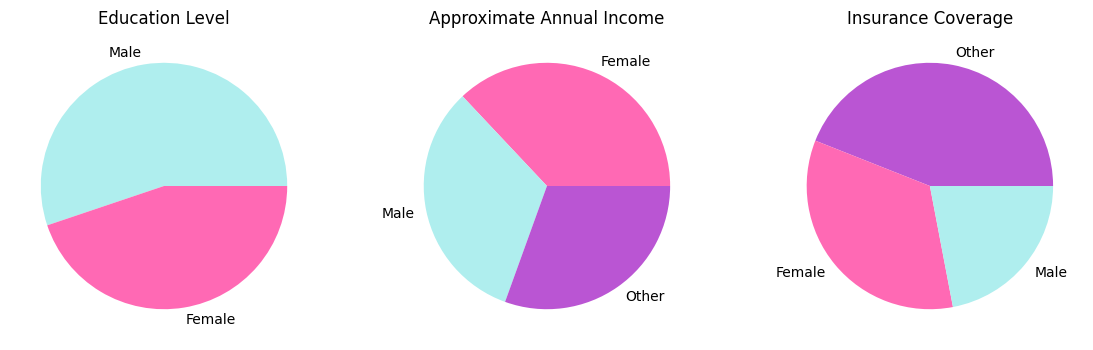

In [83]:
na_analysis = data[['Gender', 'Education Level', 'Approximate Annual Income', 'Insurance Coverage']].fillna('Empty')
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(14,4))
pie_colors = {'Male': 'paleturquoise', 'Female': 'hotpink', 'Other': 'mediumorchid'}

for i in range(3):
    ax = [ax1,ax2,ax3][i]
    col = ['Education Level', 'Approximate Annual Income', 'Insurance Coverage'][i]
    pie_data = na_analysis[na_analysis[col]=='Empty']['Gender'].value_counts().reset_index()
    colors = [pie_colors[label] for label in pie_data['Gender']]
    ax.pie(pie_data.iloc[:,1], labels=pie_data.iloc[:,0], colors=colors)
    ax.set_title(col)
plt.show()

The missing values in these columns don't seem to be dependent on gender, so they could be MCAR

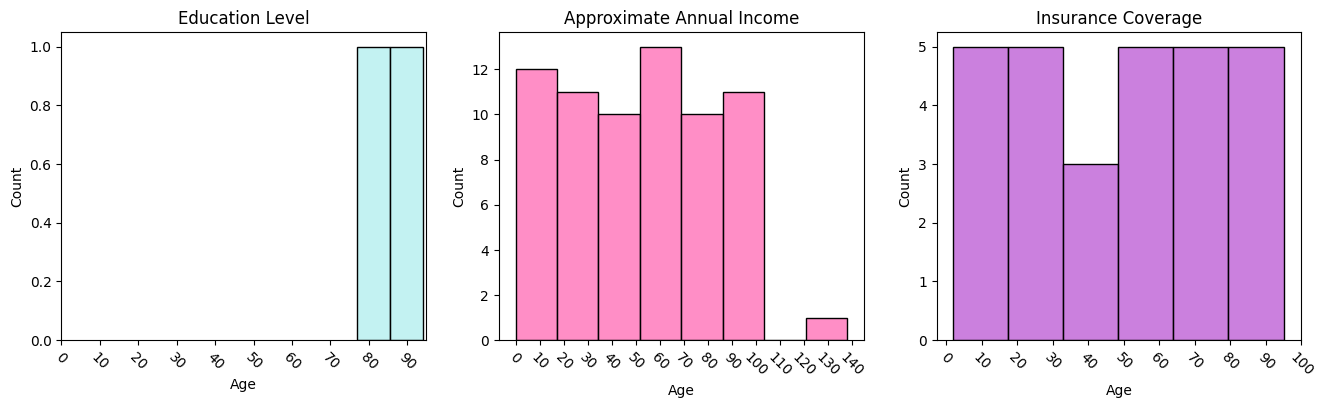

In [86]:
na_analysis = data[['Age', 'Education Level', 'Approximate Annual Income', 'Insurance Coverage']].fillna('Empty')
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(16,4))
colors=['paleturquoise', 'hotpink', 'mediumorchid']

for i in range(3):
    ax = [ax1,ax2,ax3][i]
    col = ['Education Level', 'Approximate Annual Income', 'Insurance Coverage'][i]
    hist_data = na_analysis[na_analysis[col]=='Empty']['Age'].value_counts().reset_index()
    sns.histplot(hist_data, ax=ax, x='Age', color=colors[i])
    ax.set_xticks(np.arange(0,hist_data.sort_values(by='Age').iloc[-1,0]+6,10))
    ax.tick_params(axis='x', labelrotation=-45)
    ax.set_title(col)
plt.show()

The missing values in Education Level seem to be dependent on Age, which makes them MAR, while the other two columns still seem to be MCAR

In [107]:
insurance = data[['Insurance Coverage', 'Insurance Provider']]
insurance['has coverage'] = ~insurance['Insurance Coverage'].isna()
insurance['has provider'] = ~insurance['Insurance Provider'].isna()

insurance['has both'] = insurance['has coverage'] & insurance['has provider']
insurance['has none'] = ~insurance['has coverage'] & ~insurance['has provider']

insurance = insurance.drop(['Insurance Coverage', 'Insurance Provider'], axis=1)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_17180\4210430016.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  insurance['has coverage'] = ~insurance['Insurance Coverage'].isna()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_17180\4210430016.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  insurance['has provider'] = ~insurance['Insurance Provider'].isna()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_17180\4210430016.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

<Axes: >

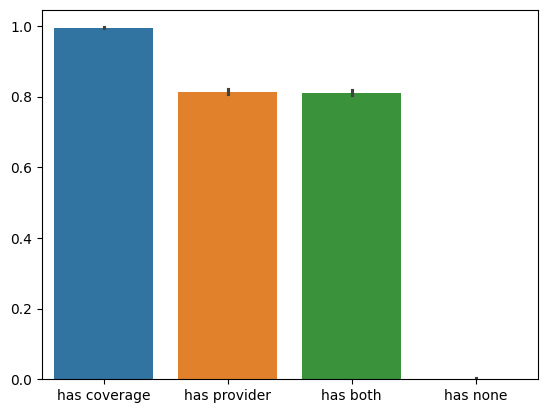

In [118]:
sns.barplot(insurance)

(missing values no insurance coverage = missing values no insurance provider?)

In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  float64       
 1   Gender                     10008 non-null  object        
 2   City of Residence          10008 non-null  object        
 3   Profession                 10008 non-null  object        
 4   Insurance Provider         8148 non-null   object        
 5   Family History             8015 non-null   object        
 6   Education Level            9979 non-null   object        
 7   Marital Status             10008 non-null  object        
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  object        
 10  Consultation Duration      10008 non-null  int64         
 11  Satisfaction Level         10008 non-null  int64         
 12  Approxi

In [ ]:
d_map = {'Age': 'int16', 'Gender': 'category', 'City of Residence': 'category', 'Profession': 'category', 
        'Insurance Provider': 'category', 'Family History': 'category', 'Education Level': 'category', 
        'Marital Status': 'category', 'Department': 'category', 'Consultation Duration': 'int16',
        'Satisfaction Level': 'category', 'Satisfaction Level': 'int8', 'Approximate Annual Income': 'float32',
        'Consultation Price': 'float16', 'Insurance Coverage': 'float16'}
data = data.astype(d_map)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10008 entries, 1482 to 1012
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Age                        10008 non-null  int16         
 1   Gender                     10008 non-null  category      
 2   City of Residence          10008 non-null  category      
 3   Profession                 10008 non-null  category      
 4   Insurance Provider         8098 non-null   category      
 5   Family History             8015 non-null   category      
 6   Education Level            9979 non-null   category      
 7   Marital Status             10008 non-null  category      
 8   Visit Date                 10008 non-null  datetime64[ns]
 9   Department                 10008 non-null  category      
 10  Consultation Duration      10008 non-null  int16         
 11  Satisfaction Level         10008 non-null  int8          
 12  Approxi